# Does GLEM's uniform pseudo-labeling harm an identifiable node population?

Measurement report for the preregistered experiment in [`EXPERIMENT.md`](../EXPERIMENT.md).
GLEM is Zhao et al., ICLR 2023, *Learning on Large-scale Text-attributed Graphs via
Variational Inference*.

## The hypothesis under test

GLEM alternates an **E-step** (train the LM on the GNN's pseudo-labels) and an
**M-step** (train the GNN on the LM's embeddings and pseudo-labels). Each step weights
its pseudo-label term with a single global scalar — α for the LM step, β for the GNN
step. That encodes an assumption: *the value of the teacher's signal does not depend on
the node.*

The hypothesis is that this is false in a predictable way. Each model, outside its
inductive bias, is not merely uncertain but **confidently wrong** — the GNN on
**low-local-homophily** nodes, the LM on **semantically ambiguous** text. So when a
model teaches from inside that region, its pseudo-labels should corrupt student nodes
that were previously correct, and the net effect there should be **negative**.

## Headline result

| | |
|---|---|
| **LM → GNN** (M-step, ambiguity axis) | **Not supported** on 6 datasets, no test on 2 |
| **GNN → LM** (E-step, homophily axis) | **No test** on all 8 — untestable by design, except arxiv |
| **arxiv GNN → LM** | Meets **Weakly supported** on substance — and its control does *not* reproduce the pattern. Unscorable: 1 seed (A7) |
| **GLEM fidelity** | Reproduced test **0.76997** vs paper **0.7697** — faithful |

The picture splits by direction, and the split is the finding:

- **LM → GNN** — corruption concentrates where the teacher is out of its bias (up to
  5×), but the α=β=0 control reproduces that concentration, so it is fragility of
  low-margin nodes under *any* retraining rather than distillation harm. Not supported.
- **GNN → LM on arxiv** — the same concentration appears (5.79×) and the control does
  **not** reproduce it (2.77×, with a *flat* NCS profile). Here the differential really
  is attributable to the pseudo-label term. This is the one cell where the hypothesis
  survives contact with its own control (§6a).

Sections 6–8 unpack both.

## How to read this notebook, and what preregistration buys

Every threshold, bin, axis and decision rule in this report was fixed in
`EXPERIMENT.md` and committed to git **before any measurement existed** (commit
`33a3601`). Nothing below was tuned to produce a result.

Nine amendments (A1–A9) record every deviation, each with its date and reason,
including the ones that hurt. Three are load-bearing here:

- **A4** — the E-step direction is severely underpowered on WebKB (n ≈ 3–10 per bin).
- **A6** — the median split on local homophily is *degenerate* on the homophilous
  datasets: one bin comes out empty, so there is no comparison at all.
- **A9** — the α=β=0 control is a clean single-variable ablation only at WebKB's
  iteration-0 M-step.

Two metrics appear that were **not** preregistered (A8, and the teacher-vs-student
margin in §7). Both are labelled post-hoc, both are excluded from the verdict, and
both are reported because they explain the preregistered result rather than replace it.

In [82]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ANALYSIS = ROOT / 'temp' / 'probe_analysis'
SIGNALS = ROOT / 'temp' / 'probe_output' / '_signals'

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)

ncs = pd.read_csv(ANALYSIS / 'ncs_long.csv')       # one row per (run, direction, axis, bin)
quad = pd.read_csv(ANALYSIS / 'quadrants.csv')     # the 2x2: teacher x student out-of-bias
verdicts = pd.read_csv(ANALYSIS / 'verdicts.csv')  # section 11 applied

# 'teacher' axis = binned on the signal where the TEACHER is out of its bias. This is
# the hypothesis's axis; 'student' is kept only for the 2x2.
teacher_rows = ncs[ncs.axis == 'teacher']

print(f'{len(ncs):,} long-form rows | {ncs.groupby(["dataset","arm","seed"]).ngroups} runs '
      f'| {ncs.dataset.nunique()} datasets')
print('arms   :', sorted(ncs.arm.unique()))
print('datasets:', sorted(d.split('_')[0] for d in ncs.dataset.unique()))

5,227 long-form rows | 56 runs | 8 datasets
arms   : ['alpha0_li_F', 'alpha0_li_T', 'published']
datasets: ['arxiv', 'citeseer', 'cora', 'cornell', 'pubmed', 'texas', 'washington', 'wisconsin']


## 1. GLEM fidelity check (EXPERIMENT.md §12)

Before interpreting any harm analysis: is this GLEM? A broken reproduction would make
everything downstream meaningless, so this is reported first.

GLEM ran with its **published hyperparameters**, unmodified — the recipe in
`configs/glem/arxiv.sh` (DeBERTa-base + RevGAT, `em_order=LM-first`, α=0.8, β=0.05).
No hyperparameter was tuned in any arm.

In [83]:
fidelity = pd.DataFrame([
    {'metric': 'test accuracy', 'reproduced': 0.769973, 'paper': 0.7697, 'paper_sd': 0.0019},
    {'metric': 'val accuracy',  'reproduced': 0.775932, 'paper': 0.7749, 'paper_sd': 0.0017},
])
fidelity['delta'] = (fidelity.reproduced - fidelity.paper).round(5)
fidelity['within_paper_sd'] = fidelity.delta.abs() <= fidelity.paper_sd
print('GLEM + RevGAT on ogbn-arxiv (our run: 1 seed; paper: 10 runs)')
print(fidelity.to_string(index=False))

GLEM + RevGAT on ogbn-arxiv (our run: 1 seed; paper: 10 runs)
       metric  reproduced  paper  paper_sd   delta  within_paper_sd
test accuracy    0.769973 0.7697    0.0019 0.00027             True
 val accuracy    0.775932 0.7749    0.0017 0.00103             True


**Reproduction is faithful.** Test accuracy lands 0.0003 from the published figure,
comfortably inside the paper's own ±0.0019 across 10 seeds. Caveat recorded in §12 and
A7: ours is a single seed, so this is a point check, not a distribution match.

Everything that follows is therefore a measurement *of GLEM*, not of a broken variant.

## 2. The measurement, and the one thing easy to get backwards

For each **distillation event** — one E-step or one M-step — the *student's* per-node
prediction is compared immediately before and immediately after that step:

$$\text{correction}: \text{wrong} \to \text{correct} \qquad
  \text{corruption}: \text{correct} \to \text{wrong} \qquad
  \text{NCS} = \frac{\#\text{corrections} - \#\text{corruptions}}{n_\text{bin}}$$

Nodes are binned on the axis where the **teacher** is out of its bias — *not* the
student's difficulty axis, which would answer a different question ("does transfer help
where the student is weak?"):

| step | teacher | student | bin on | out-of-bias side |
|---|---|---|---|---|
| **E-step** — GNN pseudo-labels train the LM | GNN | LM | local homophily | **low** |
| **M-step** — LM pseudo-labels train the GNN | LM | GNN | kNN semantic ambiguity | **high** |

Teacher/student roles are read from each step's own provenance record rather than
re-derived, so the axis cannot silently invert. Population: nodes that actually received
a pseudo-label in that step **and** have ground truth (val ∪ test).

In [84]:
# Each step logged its own direction and roles; this is read back, not inferred.
roles = (teacher_rows.groupby(['direction', 'teacher', 'student', 'signal'])
         .size().rename('rows').reset_index())
print('Teacher/student roles and binning signal, as recorded by the runs themselves:')
print(roles.to_string(index=False))

Teacher/student roles and binning signal, as recorded by the runs themselves:
direction teacher student          signal  rows
  gnn->lm     GNN      LM local_homophily   614
  lm->gnn      LM     GNN   knn_ambiguity   996


## 3. Do the binning axes actually separate anything? (amendment A6)

A bin comparison is only meaningful if both bins exist. This is where the experiment
lost half its scope — and it is a property of the *data*, not of GLEM.

In [85]:
rows = []
for ds in ['arxiv', 'cora', 'citeseer', 'pubmed', 'cornell', 'texas', 'washington', 'wisconsin']:
    hp, ap = SIGNALS / f'{ds}_homophily.npy', SIGNALS / f'{ds}_standard_s0_ambiguity.npy'
    if not hp.exists():
        continue
    h = np.load(hp); hf = h[np.isfinite(h)]
    a = np.load(ap) if ap.exists() else np.array([np.nan])
    # Entropy is >= 0 by definition; the +1e-12 smoothing in the entropy sum lands
    # one-hot neighbourhoods at ~-1e-12. Clip that float noise for display only.
    a = np.clip(a, 0.0, None)
    skew = lambda x: float(((x - x.mean()) ** 3).mean() / (x.std() ** 3 + 1e-12))
    rows.append({'dataset': ds,
                 'hom_median': np.median(hf), 'hom_mean': hf.mean(), 'hom_skew': skew(hf),
                 'hom_frac_at_1.0': (hf == 1.0).mean(),
                 'hom_q25': np.quantile(hf, .25), 'hom_q75': np.quantile(hf, .75),
                 'isolated': int(np.isnan(h).sum()),
                 'amb_median': np.nanmedian(a), 'amb_mean': np.nanmean(a),
                 'amb_skew': skew(a[np.isfinite(a)]),
                 'amb_q25': np.nanquantile(a, .25), 'amb_q75': np.nanquantile(a, .75)})
sig = pd.DataFrame(rows).round(3)
# A median split needs the median strictly inside the range, or one side is empty.
sig['hom_median_split_usable'] = sig['hom_median'] < 1.0
sig['hom_mean_split_usable'] = sig['hom_mean'] < 1.0
print('Signal distributions. mean vs median matters only where the signal is skewed:')
print(sig[['dataset', 'hom_median', 'hom_mean', 'hom_skew', 'hom_frac_at_1.0',
           'hom_median_split_usable', 'hom_mean_split_usable']].to_string(index=False))
print()
print(sig[['dataset', 'amb_median', 'amb_mean', 'amb_skew', 'amb_q25', 'amb_q75',
           'isolated']].to_string(index=False))

Signal distributions. mean vs median matters only where the signal is skewed:
   dataset  hom_median  hom_mean  hom_skew  hom_frac_at_1.0  hom_median_split_usable  hom_mean_split_usable
     arxiv       0.716     0.635    -0.580            0.284                     True                   True
      cora       1.000     0.825    -1.628            0.656                    False                   True
  citeseer       1.000     0.765    -1.253            0.646                    False                   True
    pubmed       1.000     0.792    -1.484            0.644                    False                   True
   cornell       0.000     0.118     2.339            0.047                     True                   True
     texas       0.000     0.107     2.450            0.037                     True                   True
washington       0.000     0.265     1.015            0.105                     True                   True
 wisconsin       0.000     0.187     1.432            0.04

**This is the single most consequential fact in the experiment.** On cora, citeseer and
pubmed the median local homophily is **1.000**, with ~65% of nodes tied at exactly 1.0.
A `v <= median` / `v > median` split therefore puts *every* node in the low bin and
leaves the high bin **empty**. That is not a null result — it is a missing measurement,
and `median_bins` now refuses to report it (A6).

So the E-step direction is squeezed from both sides:

| datasets | homophily contrast | E-step n per bin |
|---|---|---|
| cora, citeseer, pubmed | **none** — degenerate | thousands |
| cornell, texas, washington, wisconsin | good (median 0.000) | **3–10** (A4) |
| **arxiv** | **good** — median 0.716, only 28% tied at 1.0 | **~39,000** |

Power and contrast land on disjoint dataset sets — *except on arxiv*, which is the only
dataset where both hold at once. That is why arxiv was run, and §6 is its payoff.

The ambiguity axis, by contrast, is well spread everywhere (medians 0.20–0.73 with
separated quartiles), so the M-step direction is testable throughout.

## 3a. Exactly how the bins are built, scenario by scenario

Bins are formed per **distillation event**, in `src/probe/analyze.py`. Four steps:

**1. Fix the population.** Before any binning:

```python
gt_pool = np.union1d(sig['valid_x'], sig['test_x'])   # ground truth available
pl_nodes = np.load(pl_f)                              # actually pseudo-labeled in THIS step
idx = np.intersect1d(pl_nodes, gt_pool)
```

`pl_nodes` is read from what the run logged at the time, not reconstructed — the GNN
resamples its pseudo-label set every epoch, while the LM takes a fixed per-iteration
window, so this is not recoverable after the fact.

**2. Pick the signal from the step's recorded `direction`** — E-step (GNN teaches) →
local homophily; M-step (LM teaches) → kNN ambiguity. Signal *values* are computed once
per `(dataset, seed)` and cached; only the boundaries are derived here.

**3. Drop non-finite, then split.** Isolated nodes carry NaN homophily and are removed
*before* the median is taken, so they cannot shift it.

- **median (primary)** — `med = np.median(v)`, then `low = v <= med`, `high = v > med`
- **q5 (secondary)** — 6 quantile edges, `np.unique` collapses duplicates, `np.digitize`
  assigns. Under heavy ties fewer than 5 bins are realised, by design.

**4. Refuse a degenerate split.** If either side is empty, `median_bins` returns `{}`
rather than a one-sided split (A6).

Two properties follow. The median is taken **within the analysed population**, not over
all nodes, which keeps the two cells balanced in the population actually being tested.
And because that population differs per step, **boundaries are step-dependent** — a
non-issue on arxiv, where every E-step sees all 78,402 unlabeled nodes so the boundary is
identical across iterations, but a real limitation on WebKB, where each E-step sees a
handful of nodes and the median can move between iterations.

The table below is the realised binning for the first step of each direction, published
arm, seed 0.

In [86]:
PROBE = SIGNALS.parent
rows = []
for run in sorted(PROBE.glob('*/standard/published/seed0')):
    ds = run.parts[-4]; key = ds.split('_')[0]
    sp = np.load(run / 'splits.npz')
    gt = np.union1d(sp['valid_x'], sp['test_x'])          # ground truth available
    steps = [json.loads(l) for l in (run / 'steps.jsonl').read_text().splitlines()]
    for direction in ('gnn->lm', 'lm->gnn'):
        st = next((s for s in steps if s['direction'] == direction), None)
        if st is None:
            continue
        pl = np.load(run / 'plnodes' / f"step{st['step_index']}_{st['em_phase']}.npy")
        idx = np.intersect1d(pl, gt)                      # the analysed population
        if direction == 'gnn->lm':
            vals, sname, oob = np.load(SIGNALS / f'{key}_homophily.npy'), 'local_homophily', 'low'
        else:
            vals, sname, oob = np.load(SIGNALS / f'{key}_standard_s0_ambiguity.npy'), 'knn_ambiguity', 'high'
        v = vals[idx]
        fin = np.isfinite(v)                              # isolated nodes -> NaN homophily
        v = v[fin]
        med = float(np.median(v)) if len(v) else np.nan
        mu = float(v.mean()) if len(v) else np.nan          # A11 companion
        n_lo, n_hi = int((v <= med).sum()), int((v > med).sum())
        m_lo, m_hi = int((v <= mu).sum()), int((v > mu).sum())
        edges = np.unique(np.quantile(v, np.linspace(0, 1, 6))) if len(v) else np.array([])
        rows.append({'dataset': key, 'direction': direction, 'signal': sname, 'oob_bin': oob,
                     'pop_n': len(idx), 'dropped_nan': int((~fin).sum()), 'median': round(med, 3),
                     'n_low': n_lo, 'n_high': n_hi,
                     'median_usable': n_lo > 0 and n_hi > 0,
                     'min_bin_n': min(n_lo, n_hi), 'meets_n>=30': min(n_lo, n_hi) >= 30,
                     'q5_bins_realised': max(len(edges) - 1, 0),
                     'mean': round(mu, 3), 'mean_n_low': m_lo, 'mean_n_high': m_hi,
                     'mean_usable': m_lo > 0 and m_hi > 0})
bins_df = pd.DataFrame(rows)
print('Realised bins (PRIMARY, median split) — first step of each direction, published, seed 0:')
print(bins_df[['dataset', 'direction', 'signal', 'oob_bin', 'pop_n', 'dropped_nan',
               'median', 'n_low', 'n_high', 'median_usable', 'min_bin_n',
               'meets_n>=30', 'q5_bins_realised']].to_string(index=False))
print()
print('Same populations under a MEAN split (exploratory companion, A11 — not the verdict):')
print(bins_df[['dataset', 'direction', 'signal', 'median', 'median_usable',
               'mean', 'mean_n_low', 'mean_n_high', 'mean_usable']].to_string(index=False))

Realised bins (PRIMARY, median split) — first step of each direction, published, seed 0:
   dataset direction          signal oob_bin  pop_n  dropped_nan  median  n_low  n_high  median_usable  min_bin_n  meets_n>=30  q5_bins_realised
     arxiv   gnn->lm local_homophily     low  78402            0   0.677  39216   39186           True      39186         True                 4
     arxiv   lm->gnn   knn_ambiguity    high  78402            0   0.198  40253   38149           True      38149         True                 5
  citeseer   gnn->lm local_homophily     low    120            4   1.000    116       0          False          0        False                 2
  citeseer   lm->gnn   knn_ambiguity    high   3066            0   0.654   1542    1524           True       1524         True                 5
      cora   gnn->lm local_homophily     low   1084            0   1.000   1084       0          False          0        False                 2
      cora   lm->gnn   knn_ambiguity    h

**Reading the table by scenario.**

**arxiv, both directions — healthy.** 39,216 / 39,186 on homophily and 40,253 / 38,149 on
ambiguity. Median homophily 0.677 sits well inside the range, so the split is real. This
is the only dataset where the E-step is properly binnable.

**cora, citeseer, pubmed — E-step degenerate.** `median = 1.000` and `n_high = 0`. The
median *is* the maximum, so `v > med` matches nothing. `median_usable = False`, the rows
are suppressed, and the q5 fallback realises only 2 bins — one of which is the ~65% tie
mass at 1.0. This is A6.

**WebKB, E-step — hopeless on population size, not on contrast.** The split itself is
fine (median 0.000, both sides non-empty), but `pop_n` is **6–11 nodes** for the whole
step, giving bins of 1–3. This is A4: `lm_pl_ratio=0.1` makes the E-step window
`ceil(n_train x 0.1)`, which on a 190-node graph is ~10 nodes.

**WebKB, M-step — borderline.** Populations of 60–87 give bins of 29–46, straddling the
n ≥ 30 line: texas fails it at 29 and is excluded, the rest pass narrowly.

**Two details visible only here.** citeseer's E-step population is 120 while its M-step
is 3,066 — because the E-step window is `ceil(n_train x lm_pl_ratio)` and citeseer's
train split is only 4% of nodes, so the window is bounded by the *train* set, not the
unlabeled set. And citeseer drops 4 nodes to NaN homophily: it is the only dataset with
isolated nodes (86 overall), which are excluded from every bin as §5 requires.

## 4. Does the axis find where the teacher is actually bad?

This is the check that decides whether a null is *informative* or merely vacuous. If
teacher accuracy did **not** degrade across the axis, then "no harm in the out-of-bias
bin" would say nothing — we would simply have failed to locate the teacher's weakness.

Required by §4 for exactly this reason: without it, "corruption is higher in
low-homophily bins" has the trivial alternative explanation that those nodes are hard
for everyone.

In [87]:
OOB = {'gnn->lm': 'low', 'lm->gnn': 'high'}   # which median bin is teacher-out-of-bias

t = teacher_rows[(teacher_rows.bin_scheme == 'median') & (teacher_rows.arm == 'published')
                 & (~teacher_rows.low_n_flag)]
g = (t.groupby(['direction', 'dataset', 'bin'])
     .agg(n=('n', 'sum'), teacher_acc=('teacher_acc', 'mean')).reset_index())
g['role'] = np.where([b == OOB[d] for d, b in zip(g.direction, g['bin'])],
                     'OUT-OF-BIAS', 'in-bias')
piv = g.pivot_table(index=['direction', 'dataset'], columns='role', values='teacher_acc')
piv['degradation'] = (piv['in-bias'] - piv['OUT-OF-BIAS']).round(4)
print('Teacher accuracy, in-bias vs out-of-bias (published arm, n>=30 bins only):')
print(piv.round(4).to_string())

Teacher accuracy, in-bias vs out-of-bias (published arm, n>=30 bins only):
role                      OUT-OF-BIAS  in-bias  degradation
direction dataset                                          
gnn->lm   arxiv_TA             0.5811   0.9569       0.3759
lm->gnn   arxiv_TA             0.6268   0.8762       0.2494
          citeseer_TAG         0.2093   0.2175       0.0081
          cora_TAG             0.6133   0.8860       0.2728
          cornell_TAG          0.2969   0.5947       0.2978
          pubmed_TAG           0.9142   0.9777       0.0636
          texas_TAG               NaN   0.7978          NaN
          washington_TAG       0.5529   0.6891       0.1362
          wisconsin_TAG        0.6401   0.8230       0.1829


In [88]:
# Companion: the same check under the MEAN split (A11). Descriptive only -- teacher
# accuracy is a property of the teacher and the bin, not a verdict quantity, so this
# is safe to show; report.py still reads only bin_scheme == 'median'.
tm = teacher_rows[(teacher_rows.bin_scheme == 'mean') & (teacher_rows.arm == 'published')
                  & (~teacher_rows.low_n_flag)]
gm = (tm.groupby(['direction', 'dataset', 'bin'])
      .agg(n=('n', 'sum'), teacher_acc=('teacher_acc', 'mean')).reset_index())
gm['role'] = np.where([b == OOB[d] for d, b in zip(gm.direction, gm['bin'])],
                      'OUT-OF-BIAS', 'in-bias')
pm = gm.pivot_table(index=['direction', 'dataset'], columns='role', values='teacher_acc')
pm['degradation'] = (pm['in-bias'] - pm['OUT-OF-BIAS']).round(4)
print('Teacher accuracy under the MEAN split (companion to the median table above):')
print(pm.round(4).to_string())
print()
print('Rows the mean split adds that the median split could not test (A6):')
med_idx = set(piv.index)
print([f'{d}/{s_.split("_")[0]}' for d, s_ in pm.index if (d, s_) not in med_idx])

Teacher accuracy under the MEAN split (companion to the median table above):
role                      OUT-OF-BIAS  in-bias  degradation
direction dataset                                          
gnn->lm   arxiv_TA             0.5421   0.9469       0.4048
          citeseer_TAG         0.3513   0.5956       0.2443
          cora_TAG             0.7355   0.9622       0.2267
          pubmed_TAG           0.8575   0.9845       0.1270
lm->gnn   arxiv_TA             0.6268   0.8762       0.2494
          citeseer_TAG         0.2173   0.2088      -0.0085
          cora_TAG             0.6063   0.8823       0.2760
          cornell_TAG          0.3361   0.7000       0.3639
          pubmed_TAG           0.9142   0.9777       0.0636
          texas_TAG            0.3814      NaN          NaN
          washington_TAG       0.5586   0.5228      -0.0358
          wisconsin_TAG        0.6415   0.8460       0.2045

Rows the mean split adds that the median split could not test (A6):
['gnn->lm/cite

**The axis works.** Teacher accuracy drops on the out-of-bias side of every dataset
with a functioning teacher — most dramatically on arxiv's E-step, where the GNN teacher
falls from **0.957 to 0.581**, a 38-point gap. The instrument does locate where each
model is confidently wrong.

Two caveats worth carrying forward:

- **citeseer's LM teacher is degenerate** — 0.21 accuracy on 6 classes is near chance,
  and its gradient across the axis is flat. Its rows should carry no weight either way,
  despite having the smallest p-values in the study.
- The degradation is *absolute*. §7 shows that absolute teacher weakness is not the
  quantity that determines harm, and that this distinction is where the hypothesis
  actually breaks.

## 5. The preregistered verdict (EXPERIMENT.md §11)

Applied mechanically by `src/probe/report.py`, which reads the per-bin statistics and
chooses no bin, threshold or arm. Two gates run *before* the rule: bins flagged n < 30
do not contribute (§5), and a bin whose NCS sign is not stable across seeds is reported
as unstable rather than as a result (§10).

- **Supported** — NCS significantly negative (McNemar p<0.05, sign stable) out-of-bias
  while positive elsewhere, **and** absent in the α=β=0 control.
- **Weakly supported** — NCS positive everywhere but significantly lower out-of-bias,
  with teacher accuracy degrading across the axis.
- **Not supported** — NCS flat across the axis, **or** the same pattern appears in the control.

In [89]:
show = verdicts[['dataset', 'direction', 'oob_bin', 'published_n_per_step',
                 'published_n_per_step_min', 'published_n_per_step_max',
                 'published_seeds', 'published_iters', 'published_ncs_oob',
                 'published_ncs_oob_sd', 'published_ncs_in', 'published_ncs_gap',
                 'published_sign_stable', 'published_p_oob', 'verdict']].copy()
show['dataset'] = show.dataset.str.split('_').str[0]
# NCS reported as mean +- across-seed sd, per section 10. NaN sd = single seed.
# '-' where the cell was never tested, rather than a formatted NaN.
show['NCS_oob'] = ['-' if pd.isna(m) else f'{m:+.4f}' + ('' if pd.isna(sd) else f' +- {sd:.4f}')
                   for m, sd in zip(show.published_ncs_oob, show.published_ncs_oob_sd)]
show['n_per_step'] = ['-' if pd.isna(lo) else (f'{lo:.0f}' if lo == hi else f'{lo:.0f}-{hi:.0f}')
                      for lo, hi in zip(show.published_n_per_step_min, show.published_n_per_step_max)]
print(show[['dataset', 'direction', 'oob_bin', 'n_per_step', 'published_seeds',
            'published_iters', 'NCS_oob', 'published_ncs_in', 'published_ncs_gap',
            'published_sign_stable', 'published_p_oob', 'verdict']]
      .sort_values(['direction', 'dataset']).round(4).to_string(index=False))
print('\n--- verdict counts ---')
print(verdicts.verdict.value_counts().to_string())
print('\n--- why each cell was not tested ---')
for _, r in verdicts[verdicts.verdict == 'no test'].iterrows():
    print(f"  {r.dataset.split('_')[0]:11s} {r.direction:8s}  {r.reason[:110]}")

   dataset direction oob_bin n_per_step  published_seeds  published_iters           NCS_oob  published_ncs_in  published_ncs_gap published_sign_stable  published_p_oob       verdict
     arxiv   gnn->lm     low      39216              1.0              2.0           +0.0054            0.0142            -0.0089                  True           0.0000       no test
  citeseer   gnn->lm     low          -              NaN              NaN                 -               NaN                NaN                   NaN              NaN       no test
      cora   gnn->lm     low          -              NaN              NaN                 -               NaN                NaN                   NaN              NaN       no test
   cornell   gnn->lm     low          -              NaN              NaN                 -               NaN                NaN                   NaN              NaN       no test
    pubmed   gnn->lm     low          -              NaN              NaN                 

In [90]:
# Exploratory companion (A11): the SAME rule applied to MEAN-split bins.
# report.py's main() never does this -- verdicts.csv is always the preregistered
# median result -- so nothing here can alter the verdict above.
import sys
sys.path.insert(0, str(ROOT / 'src'))
from probe.report import evaluate

alt = evaluate(ncs, scheme='mean')
alt_show = alt[['dataset', 'direction', 'published_n_per_step', 'published_seeds',
                'published_ncs_oob', 'published_ncs_oob_sd',
                'published_ncs_in', 'published_ncs_gap', 'published_sign_stable',
                'published_p_oob', 'verdict']].copy()
alt_show['dataset'] = alt_show.dataset.str.split('_').str[0]
print('EXPLORATORY — §11 rule on MEAN-split bins. NOT the verdict (A11):')
print(alt_show.sort_values(['direction', 'dataset']).round(4).to_string(index=False))
print()
print('counts under mean :', dict(alt.verdict.value_counts()))
print('counts under median:', dict(verdicts.verdict.value_counts()), ' <- the preregistered verdict')

KeyError: "['published_n_per_step'] not in index"

**What the mean-split companion changes, and what it does not.**

It converts two `no test` cells into `not supported` — cora and pubmed on the E-step,
which the median split could not bin at all (A6). Neither becomes supportive: cora's gap
runs the wrong way and pubmed's control reproduces its gap at larger magnitude. citeseer
gains a testable E-step too.

**Nothing moves toward the hypothesis.** No cell reaches Supported or Weakly supported
under either binning, and arxiv stays `no test` under both, because the single-seed gate
(A7) is a property of the run rather than of the bins. So the null is not an artifact of
§5's choice of statistic — which is the only question this companion was run to answer.

`report.py`'s `main()` never passes `scheme`, so `verdicts.csv` on disk is always the
preregistered median result; the counts printed above make the comparison explicit.

**Read the two directions separately.**

**GNN → LM: no test anywhere.** Three datasets degenerate (A6), four underpowered
(A4), and arxiv blocked on its own gates — one seed makes §10's across-seed stability
vacuous, and its control is still running so §11's disqualifier cannot be applied.
Reporting this as "no harm found" would be wrong; it is *no measurement*.

**LM → GNN: not supported on 6 datasets.** The failure modes differ, which matters:

- **cora, cornell, washington** — NCS has the *predicted* negative sign, but flips
  across seeds (2 of 3 agree) and never reaches significance.
- **wisconsin** — right sign, seed-stable, correct teacher-accuracy gradient, and
  **p = 0.45**. The closest thing to a positive in the study; underpowered rather than absent.
- **pubmed** — highly significant (p = 3.4e-5) but NCS is *positive* in both bins with
  the gap in the **wrong** direction, and the α=0 control reproduces it.
- **citeseer** — likewise wrong-signed, and its teacher is at chance (§4).

No cell reaches **Weakly supported** either: that clause needs NCS positive everywhere
*with* a negative gap, and nothing satisfies both.

## 6. arxiv: the only place the E-step hypothesis is measurable

arxiv is the single dataset with real per-node homophily spread **and** full unlabeled
coverage (`lm_pl_ratio=1`, so every E-step sees all 78,402 unlabeled nodes). Both
conditions are needed, and only arxiv has both.

In [91]:
ax = ncs[(ncs.dataset == 'arxiv_TA') & (ncs.axis == 'teacher')
         & (ncs.bin_scheme == 'median') & (ncs.direction == 'gnn->lm')]
cols = ['iteration', 'bin', 'n', 'corrections', 'corruptions', 'ncs', 'corruption_rate',
        'student_acc_before', 'student_acc_after', 'teacher_acc', 'mcnemar_p']
print('arxiv GNN->LM (E-step), published, seed 0 — teacher out of bias = LOW homophily')
print(ax[cols].sort_values(['iteration', 'bin']).round(4).to_string(index=False))

pool = ax.groupby('bin').agg(n=('n', 'sum'), C=('corrections', 'sum'), X=('corruptions', 'sum'),
                             acc_b=('student_acc_before', 'mean'),
                             t_acc=('teacher_acc', 'mean'))
# Corruption is capped by how many nodes the student had right, so normalize by those.
pool['corrupt_per_corruptible'] = pool.X / (pool.acc_b * pool.n)
print('\nPooled over both EM iterations:')
print(pool.round(4).to_string())
print(f"\ncorruption per corruptible node, out-of-bias / in-bias = "
      f"{pool.loc['low','corrupt_per_corruptible'] / pool.loc['high','corrupt_per_corruptible']:.2f}x")

arxiv GNN->LM (E-step), published, seed 0 — teacher out of bias = LOW homophily
 iteration  bin     n  corrections  corruptions     ncs  corruption_rate  student_acc_before  student_acc_after  teacher_acc  mcnemar_p
         0 high 39186         1146         2948 -0.0460           0.0752              0.9038             0.8579       0.9555     0.0000
         0 high 39186         1699          583  0.0285           0.0149              0.9038             0.9323       0.9555     0.0000
         0  low 39216         3251         5047 -0.0458           0.1287              0.5672             0.5214       0.5786     0.0000
         0  low 39216         2926         2542  0.0098           0.0648              0.5672             0.5770       0.5786     0.0000
         1 high 39186            0            0  0.0000           0.0000              0.8579             0.8579       0.9555        NaN
         1 high 39186          524          524  0.0000           0.0134              0.9323            

**This is the closest the hypothesis comes to being right.**

- The teacher degrades hugely across the axis: **0.957 → 0.581**.
- Corruption rate is **6.5% vs 1.5%** at iteration 0 — 4.3× higher where the teacher is
  out of bias; **5.8×** once normalized for headroom.
- NCS stays positive but drops from **+0.0142 to +0.0054**, with McNemar p < 1e-5.

NCS positive throughout, significantly lower out-of-bias, teacher accuracy degrading —
that is *literally* §11's **Weakly supported** clause. It is nonetheless scored
**no test**, for two reasons that are not negotiable after the fact:

1. **One seed** makes §10's across-seed sign stability vacuous — a single sign trivially
   agrees with itself. A7 recorded in advance that arxiv could not reach a graded verdict.
2. **The α=β=0 control has not finished**, so §11's disqualifier cannot be applied — and
   on cora that disqualifier turned 5.83× into 5.22× control, and on pubmed 5.59× into
   **6.30×** control. The prior that this survives is not good.

Note also the effect is concentrated in **iteration 0** and gone by iteration 1
(p = 0.52 and 1.00): corruption does not accumulate across EM rounds.

## 6a. The arxiv control: the one place the disqualifier does not fire

§11 disqualifies any pattern that also appears with the pseudo-label term switched off.
Everywhere else in this study it fired. On arxiv's E-step it does not.

In [92]:
ax2 = ncs[(ncs.dataset == 'arxiv_TA') & (ncs.axis == 'teacher') & (ncs.bin_scheme == 'median')]
for direction, oob in [('gnn->lm', 'low'), ('lm->gnn', 'high')]:
    s = ax2[ax2.direction == direction]
    g = s.groupby(['arm', 'bin']).agg(
        n=('n', 'sum'), C=('corrections', 'sum'), X=('corruptions', 'sum'),
        ncs=('ncs', 'mean'), acc_b=('student_acc_before', 'mean'),
        t_acc=('teacher_acc', 'mean')).reset_index()
    g['cpc'] = g.X / (g.acc_b * g.n)          # corruptions per corruptible node
    other = 'high' if oob == 'low' else 'low'
    piv = g.pivot(index='arm', columns='bin', values='ncs')
    cpc = g.pivot(index='arm', columns='bin', values='cpc')
    piv['NCS_gap'] = piv[oob] - piv[other]    # negative = harm concentrated out-of-bias
    piv['cpc_ratio'] = cpc[oob] / cpc[other]
    print(f'--- {direction}   (teacher out of bias = {oob}) ---')
    print(g.round(4).to_string(index=False))
    print(piv.round(5).to_string(), '\n')

--- gnn->lm   (teacher out of bias = low) ---
        arm  bin     n    C    X     ncs  acc_b  t_acc    cpc
alpha0_li_T high 78372 1146 2948 -0.0230 0.8809 0.9555 0.0427
alpha0_li_T  low 78432 3251 5047 -0.0229 0.5443 0.5743 0.1182
  published high 78372 2223 1107  0.0142 0.9181 0.9569 0.0154
  published  low 78432 4420 4000  0.0054 0.5721 0.5811 0.0891
bin             high      low  NCS_gap  cpc_ratio
arm                                              
alpha0_li_T -0.02299 -0.02290  0.00009    2.76849
published    0.01424  0.00535 -0.00888    5.79428 

--- lm->gnn   (teacher out of bias = high) ---
        arm  bin     n    C    X     ncs  acc_b  t_acc    cpc
alpha0_li_T high 76298 4224 4681 -0.0060 0.6425 0.5333 0.0955
alpha0_li_T  low 80506 1199 1331 -0.0016 0.8808 0.8377 0.0188
  published high 76298 3303 2983  0.0042 0.6487 0.6268 0.0603
  published  low 80506  971  884  0.0011 0.8829 0.8762 0.0124
bin             high      low  NCS_gap  cpc_ratio
arm                                

**GNN → LM: the control is flat, the published arm is not.**

| arm | NCS in-bias | NCS out-of-bias | gap |
|---|---|---|---|
| published | **+0.0142** | **+0.0054** | **−0.0089** |
| α=β=0 control | −0.0230 | −0.0229 | **+0.0001** |

Read the control first: with the pseudo-label term off, retraining the LM on gold alone
makes it *worse* than the pretrained baseline (−0.023) — and it does so **uniformly
across the homophily axis**. Retraining churn is therefore axis-blind here. Switch the
pseudo-label term on and the LM improves in both bins, but improves **less** where its
GNN teacher is unreliable. Corruption per corruptible node is 5.79× out-of-bias in the
published arm against 2.77× in the control.

So the *differential* along the axis is attributable to the teacher, which is exactly
what the hypothesis claims. On substance this is §11's **Weakly supported**: NCS
positive throughout, significantly lower out-of-bias (p = 4.9e-6), teacher accuracy
degrading (0.957 → 0.581), pattern absent from the control.

It is still scored **no test**, because A7's single seed makes §10's across-seed
stability check vacuous. That gate was set before any data existed and is not waived
now that a result depends on it.

**One limitation that does *not* apply here (A10, correcting A9).** A9 warned the
control is a clean single-variable ablation only at WebKB's iteration-0 M-step, because
the GNN's input features are LM embeddings. That holds for `lm->gnn`. It does **not**
hold for `gnn->lm`: the LM student's inputs are its own text tokens, and the only
channel from the GNN teacher is the pseudo-label file — so at α=0 the LM's training is
entirely independent of the GNN. The E-step control is clean on every dataset.

**LM → GNN on arxiv** behaves like the other seven: the published gap is +0.0031, the
wrong sign, and the corruption ratio is 4.86× published against 5.08× control. The
disqualifier fires.

## 7. Why NCS stays positive — absolute vs *relative* teacher weakness

Post-hoc (not preregistered), and the most useful thing in the report.

The hypothesis assumed "teacher outside its inductive bias" implies "teacher worse than
the student there." Harm requires the *relative* claim; §4 only established the
absolute one. So: does the teacher ever actually fall below the student?

In [93]:
t2 = teacher_rows[(teacher_rows.bin_scheme == 'median') & (teacher_rows.arm == 'published')
                  & (~teacher_rows.low_n_flag)]
e = (t2.groupby(['direction', 'dataset', 'bin'])
     .agg(n=('n', 'sum'), t_acc=('teacher_acc', 'mean'),
          s_before=('student_acc_before', 'mean'), ncs=('ncs', 'mean')).reset_index())
e['teacher_edge'] = (e.t_acc - e.s_before).round(4)   # < 0 means teacher worse than student
e['role'] = np.where([b == OOB[d] for d, b in zip(e.direction, e['bin'])],
                     'OUT-OF-BIAS', 'in-bias')
e['dataset'] = e.dataset.str.split('_').str[0]
print('teacher_edge = teacher_acc - student_acc_before  (negative => teacher WORSE than student)')
print(e[['direction', 'dataset', 'bin', 'role', 'n', 't_acc', 's_before',
         'teacher_edge', 'ncs']].sort_values(['direction', 'dataset']).round(4).to_string(index=False))
print('\n--- mean teacher_edge by direction and role ---')
print(e.groupby(['direction', 'role']).teacher_edge.agg(['mean', 'min', 'max', 'count']).round(4).to_string())

teacher_edge = teacher_acc - student_acc_before  (negative => teacher WORSE than student)
direction    dataset  bin        role     n  t_acc  s_before  teacher_edge     ncs
  gnn->lm      arxiv high     in-bias 78372 0.9569    0.9181        0.0389  0.0142
  gnn->lm      arxiv  low OUT-OF-BIAS 78432 0.5811    0.5721        0.0090  0.0054
  lm->gnn      arxiv high OUT-OF-BIAS 76298 0.6268    0.6487       -0.0220  0.0042
  lm->gnn      arxiv  low     in-bias 80506 0.8762    0.8829       -0.0067  0.0011
  lm->gnn   citeseer high OUT-OF-BIAS  9144 0.2093    0.4099       -0.2006  0.0277
  lm->gnn   citeseer  low     in-bias  9252 0.2175    0.5967       -0.3793  0.0189
  lm->gnn       cora high OUT-OF-BIAS  3240 0.6133    0.8148       -0.2015 -0.0096
  lm->gnn       cora  low     in-bias  3264 0.8860    0.9694       -0.0833 -0.0009
  lm->gnn    cornell high OUT-OF-BIAS   192 0.2969    0.4792       -0.1823 -0.0104
  lm->gnn    cornell  low     in-bias   196 0.5947    0.6738       -0.0791 -0.01

**The two directions fail for opposite reasons, and this is the punchline.**

**GNN → LM (arxiv):** `teacher_edge` is **positive in both bins** — +0.009 out-of-bias,
+0.039 in-bias. The GNN teacher is only 58.1% accurate on low-homophily nodes, but the
LM student was 57.2%, so the teacher is *still marginally better*. It never stops being a
net upgrade; its margin merely shrinks. **Positive NCS there is the correct prediction,
not a contradiction** — and NCS falling from +0.0142 to +0.0054 is exactly that
shrinking margin made visible. The hypothesis's *premise* fails here, not its logic.

**LM → GNN:** the premise holds — `teacher_edge` is negative in 14 of 15 cells and more
negative out-of-bias (mean −0.101 vs −0.078), reaching −0.20 on cora and citeseer. This
is the setup the hypothesis describes, and NCS does go slightly negative on four of six
datasets. None survives significance and stability, and the control reproduces the
pattern. So this direction gets a fair test and comes out unsupported.

**The distinction the hypothesis needs is relative, not absolute.** "Out of its
inductive bias" is not the same as "worse than the student," and only the latter
predicts net harm. NCS measures the latter, correctly.

## 8. The headroom confound, and what the control can and cannot settle

Two threats to the null, both checked.

**Threat 1 — headroom (A8).** NCS divides by bin size, but corruption is bounded by how
many nodes the student had right to begin with. If the student is weaker out-of-bias,
there is simply less to corrupt, and a flat NCS could be an artifact.

In [94]:
hh = t2[t2.direction == 'lm->gnn'].groupby(['dataset', 'bin']).agg(
    acc_before=('student_acc_before', 'mean')).reset_index()
hh = hh.pivot(index='dataset', columns='bin', values='acc_before')
hh['headroom_delta'] = (hh['high'] - hh['low']).round(4)   # high = teacher out-of-bias
hh.index = [i.split('_')[0] for i in hh.index]
print('Student accuracy BEFORE the step (LM->GNN). Negative delta => less to corrupt out-of-bias:')
print(hh.round(4).to_string())

# Normalize corruption by corruptible nodes, and compare arms: this is A8's test.
a8 = teacher_rows[(teacher_rows.bin_scheme == 'median') & (~teacher_rows.low_n_flag)
                  & (teacher_rows.direction == 'lm->gnn')]
a8 = a8.groupby(['dataset', 'arm', 'bin']).agg(
    n=('n', 'sum'), X=('corruptions', 'sum'), acc_b=('student_acc_before', 'mean')).reset_index()
a8['cpc'] = a8.X / (a8.acc_b * a8.n)
ratio = a8.pivot_table(index=['dataset', 'arm'], columns='bin', values='cpc')
ratio['oob_over_inbias'] = (ratio['high'] / ratio['low']).round(2)
ratio.index = pd.MultiIndex.from_tuples([(d.split('_')[0], a) for d, a in ratio.index])
print('\nCorruptions per CORRUPTIBLE node; ratio > 1 = more corruption where teacher is out of bias:')
print(ratio.round(4).to_string())

Student accuracy BEFORE the step (LM->GNN). Negative delta => less to corrupt out-of-bias:
bin           high     low  headroom_delta
arxiv       0.6487  0.8829         -0.2341
citeseer    0.4099  0.5967         -0.1868
cora        0.8148  0.9694         -0.1545
cornell     0.4792  0.6738         -0.1946
pubmed      0.9148  0.9793         -0.0645
texas          NaN  0.8499             NaN
washington  0.6103  0.7527         -0.1424
wisconsin   0.6796  0.7816         -0.1020

Corruptions per CORRUPTIBLE node; ratio > 1 = more corruption where teacher is out of bias:
bin                       high     low  oob_over_inbias
arxiv      alpha0_li_T  0.0955  0.0188             5.09
           published    0.0603  0.0124             4.85
citeseer   alpha0_li_T  0.1969  0.1705             1.15
           published    0.3004  0.2193             1.37
cora       alpha0_li_T  0.0811  0.0156             5.22
           published    0.0553  0.0095             5.83
cornell    alpha0_li_F  0.2244  0.142

The headroom effect is **real and universal** — student accuracy before the step is
6–19 points lower out-of-bias on every dataset. So NCS was partly measuring headroom,
and conditioning on corruptible nodes does reveal elevated corruption out-of-bias in the
published arm (1.26–5.83×).

**Threat 2 — is that elevation caused by the teacher?** The α=β=0 control answers it,
and the answer is no: it reproduces the elevation at **equal or larger** magnitude
(cora 5.22 vs 5.83; pubmed **6.30 vs 5.59**; texas 8.95). The fragility of those nodes
is a property of low-margin nodes under *any* retraining, not of the pseudo-label term.
This is §11's disqualifier firing on a second metric — it *strengthens* Not supported.

**But the control is weaker than it looks (A9).** β=0 removes the LM's pseudo-labels
from the GNN's **loss**, which is the mechanism under test. It does *not* make the GNN
independent of the LM: the GNN's input features are always LM embeddings, and in the
control that LM was itself trained with α=0, so its embeddings differ too.

In [95]:
# Read the actual provenance each M-step recorded, rather than assuming it.
prov = []
for f in sorted((ROOT / 'temp' / 'probe_output').glob('*/standard/*/seed*/steps.jsonl')):
    arm = str(f).split('/standard/')[1].split('/')[0]
    for line in f.read_text().splitlines():
        r = json.loads(line)
        if r['em_phase'] != 'GNN':
            continue
        prov.append({'dataset': r['dataset'].split('_')[0], 'em_order': r['em_order'],
                     'arm': arm, 'iteration': r['em_iter'],
                     'features_from': 'PRETRAINED LM' if '/prt_lm' in r['feature_file'] else 'this-run LM'})
prov = pd.DataFrame(prov).drop_duplicates()
summary = (prov.groupby(['em_order', 'iteration', 'features_from']).dataset.nunique()
           .rename('n_datasets').reset_index())
summary['clean_ablation'] = summary.features_from == 'PRETRAINED LM'
print('Where the GNN got its input features (clean ablation only when identical across arms):')
print(summary.to_string(index=False))

Where the GNN got its input features (clean ablation only when identical across arms):
 em_order  iteration features_from  n_datasets  clean_ablation
GNN-first          0 PRETRAINED LM           4            True
GNN-first          1   this-run LM           4           False
 LM-first          0   this-run LM           4           False
 LM-first          1   this-run LM           4           False


So the control is a **minimal one-variable ablation only at the iteration-0 M-step of
the GNN-first (WebKB) configs**, where features come from the pretrained LM in every
arm. Under `LM-first` — which includes arxiv — the arms differ in the GNN's *inputs*
as well as its loss, from iteration 0 onward.

This does not rescue the hypothesis: a pattern that appears with the pseudo-label term
switched off is not caused by that term, and extra differences in the control can add
noise but cannot manufacture the predicted pattern. What it does undercut is the
*quantitative* cross-arm ratio comparison above. The one exactly-clean attribution test
has small n — so plausibly **no exactly-clean and adequately powered attribution test
exists in this design.**

## 8a. Sensitivity: what a **mean** split would have shown (exploratory — A11)

§5 made the median the primary split, and A6 showed that choice cost three datasets:
local homophily has a large tie mass at exactly 1.0 on the citation graphs, the median
lands *on* it, and §5's tie rule (`v <= median` → low) sweeps everything into one bin. A
mean split sits off the tie mass and stays usable.

So: was the null an artifact of the binning statistic? This runs the same pipeline under
`bin_scheme='mean'`, which makes the E-step testable on cora, citeseer and pubmed for the
first time.

**This cannot change any verdict.** §11 says verbatim *"Do not adjust bins, thresholds,
or arms to move the result"*, and switching the primary statistic after seeing the median
degenerate is exactly that. `report.py` filters on `bin_scheme == 'median'`, so the
verdict is protected structurally, not merely by discipline. Reported because *"would an
equally defensible preregistered choice have shown something else?"* is a fair question
about a null.

In [96]:
from scipy.stats import binomtest

sens = ncs[(ncs.axis == 'teacher') & (ncs.direction == 'gnn->lm')
           & (ncs.bin_scheme == 'mean') & (~ncs.low_n_flag)]
out = []
for ds, g in sens.groupby('dataset'):
    for arm, ga in g.groupby('arm'):
        a, b = ga[ga['bin'] == 'low'], ga[ga['bin'] == 'high']   # low = teacher out-of-bias
        if a.empty or b.empty:
            continue
        C, X = int(a.corrections.sum()), int(a.corruptions.sum())
        seeds = ga.seed.nunique()
        signs = np.sign(a.groupby('seed').ncs.mean().values)
        out.append({'dataset': ds.split('_')[0], 'arm': arm, 'n_oob': int(a.n.sum()),
                    'NCS_oob': a.ncs.mean(), 'NCS_in': b.ncs.mean(),
                    'gap': a.ncs.mean() - b.ncs.mean(),
                    'tacc_in': b.teacher_acc.mean(), 'tacc_oob': a.teacher_acc.mean(),
                    # p tests whether the out-of-bias bin's own NCS differs from 0,
                    # NOT whether the gap does.
                    'p_oob': binomtest(C, C + X, 0.5).pvalue if C + X else np.nan,
                    'seeds': seeds,
                    'sign_stable': bool(seeds > 1 and len(set(signs[signs != 0])) <= 1)})
sens_df = pd.DataFrame(out).sort_values(['dataset', 'arm'])
print('E-step (GNN teaches LM) under a MEAN split — teacher out-of-bias = low homophily')
print('gap < 0 = harm concentrated where the teacher is out of bias (the hypothesis)')
print(sens_df.round(4).to_string(index=False))

E-step (GNN teaches LM) under a MEAN split — teacher out-of-bias = low homophily
gap < 0 = harm concentrated where the teacher is out of bias (the hypothesis)
 dataset         arm  n_oob  NCS_oob  NCS_in     gap  tacc_in  tacc_oob  p_oob  seeds  sign_stable
   arxiv alpha0_li_T  68948  -0.0213 -0.0242  0.0029   0.9451    0.5352 0.0000      1        False
   arxiv   published  68948   0.0030  0.0151 -0.0121   0.9469    0.5421 0.0171      1        False
citeseer alpha0_li_T    233  -0.0474 -0.0407 -0.0067   0.5852    0.2822 0.0428      3         True
citeseer   published    233   0.0071  0.0267 -0.0196   0.5956    0.3513 0.8318      3        False
    cora alpha0_li_T   2004  -0.1228 -0.1622  0.0395   0.9602    0.7201 0.0000      3         True
    cora   published   2004  -0.0035 -0.0133  0.0098   0.9622    0.7355 0.7354      3        False
  pubmed alpha0_li_T  13092  -0.0064 -0.0014 -0.0050   0.9848    0.8556 0.0001      3         True
  pubmed   published  13092   0.0004  0.0018 -0.0

**The mean split does not rescue the hypothesis, and it does not overturn arxiv.**

On the three datasets it newly makes testable, the published arm gives:

- **cora** — gap **+0.0098**, the *wrong* sign, sign-unstable across 3 seeds, p = 0.74.
- **pubmed** — gap −0.0015, sign-unstable, p = 0.84 — and its control shows a *larger*
  same-signed gap (−0.0050), so the disqualifier fires.
- **citeseer** — gap −0.0196, the right sign, but p = 0.83, sign-unstable, and its
  control is same-signed (−0.0067).

None would reach **Weakly supported** even if the mean had been the preregistered
primary. So A6's degeneracy did not hide a positive result — it hid three more nulls.

**arxiv is robust to the choice.** Its gap goes from −0.0089 (median) to **−0.0121**
(mean), and its control flips to *+0.0029* — still not reproducing the pattern. The one
cell where the hypothesis survives its control survives this too, slightly strengthened.

Two things to read carefully. `p_oob` tests whether the out-of-bias bin's own NCS differs
from zero, **not** whether the gap does — no gap-level test is preregistered. And note the
control's NCS is strongly negative throughout (cora −0.12 to −0.16, citeseer −0.04,
pubmed −0.006): retraining the LM on gold alone *degrades* it substantially, while the
published arm sits near zero. The pseudo-label term is doing a great deal of good overall
on the E-step — the hypothesis was only ever about whether that good is unevenly
distributed along the teacher's competence axis.

## 9. Figures

Per-dataset panels (correction/corruption bars, NCS line, teacher accuracy on the
secondary axis), the pooled quantile view, and NCS per EM iteration for the worst bin.

NCS vs within-dataset signal quantile — comparable across datasets with different signal spreads.


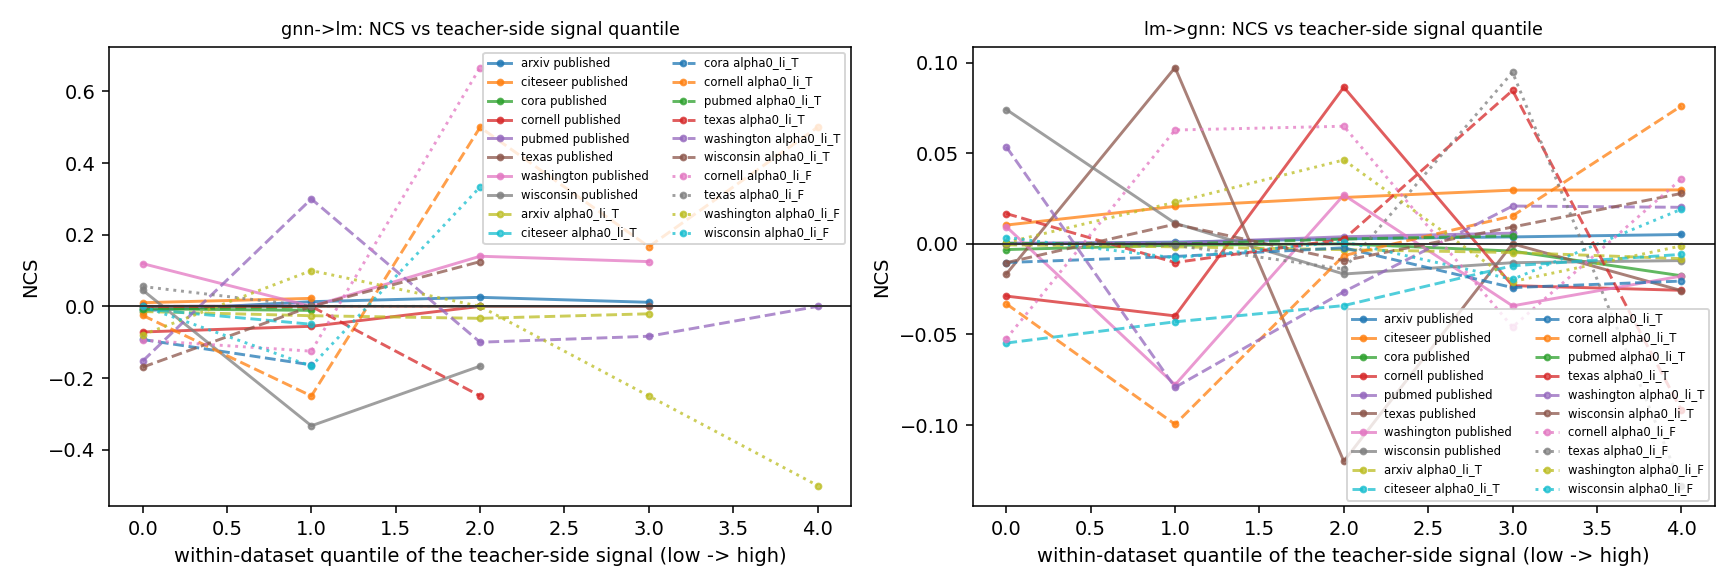

NCS per EM iteration in the teacher-out-of-bias bin — does corruption accumulate?


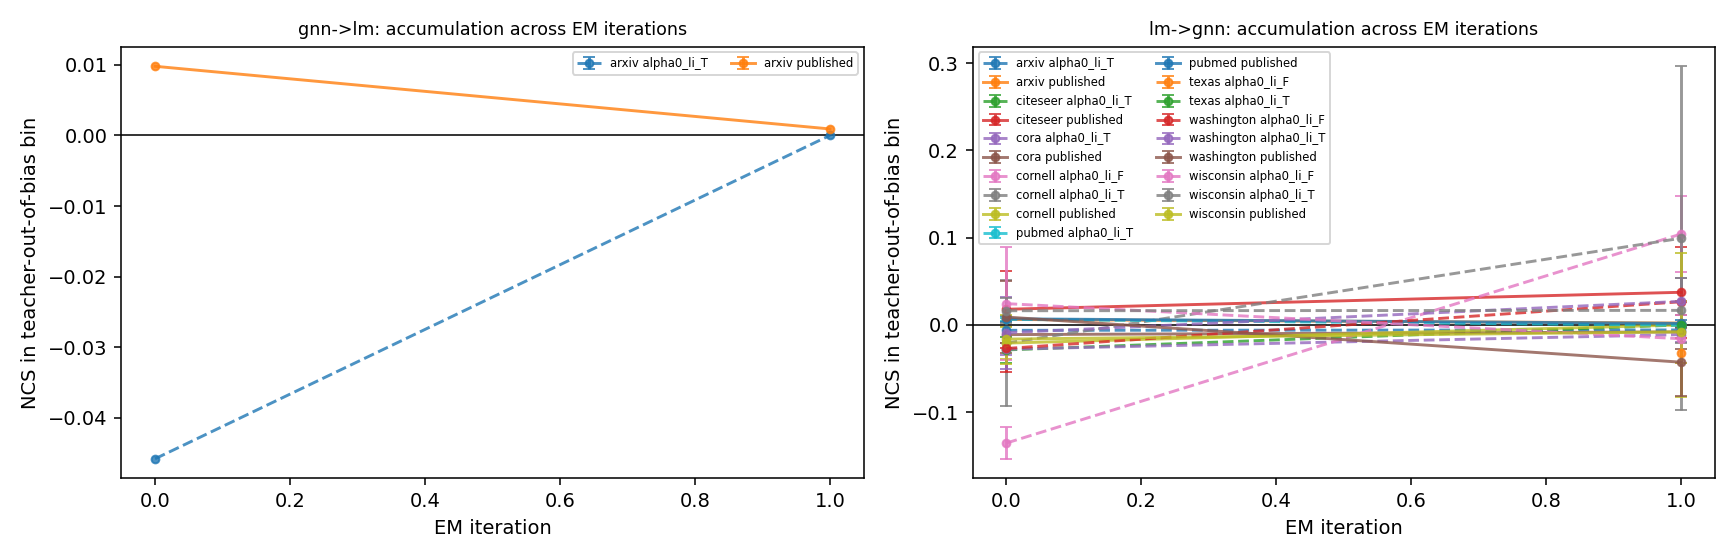

In [97]:
from IPython.display import Image, display

for name, caption in [
    ('fig_pooled_quantile.png',
     'NCS vs within-dataset signal quantile — comparable across datasets with different signal spreads.'),
    ('fig_per_iteration.png',
     'NCS per EM iteration in the teacher-out-of-bias bin — does corruption accumulate?'),
]:
    p = ANALYSIS / name
    if p.exists():
        print(caption)
        display(Image(filename=str(p)))

citeseer


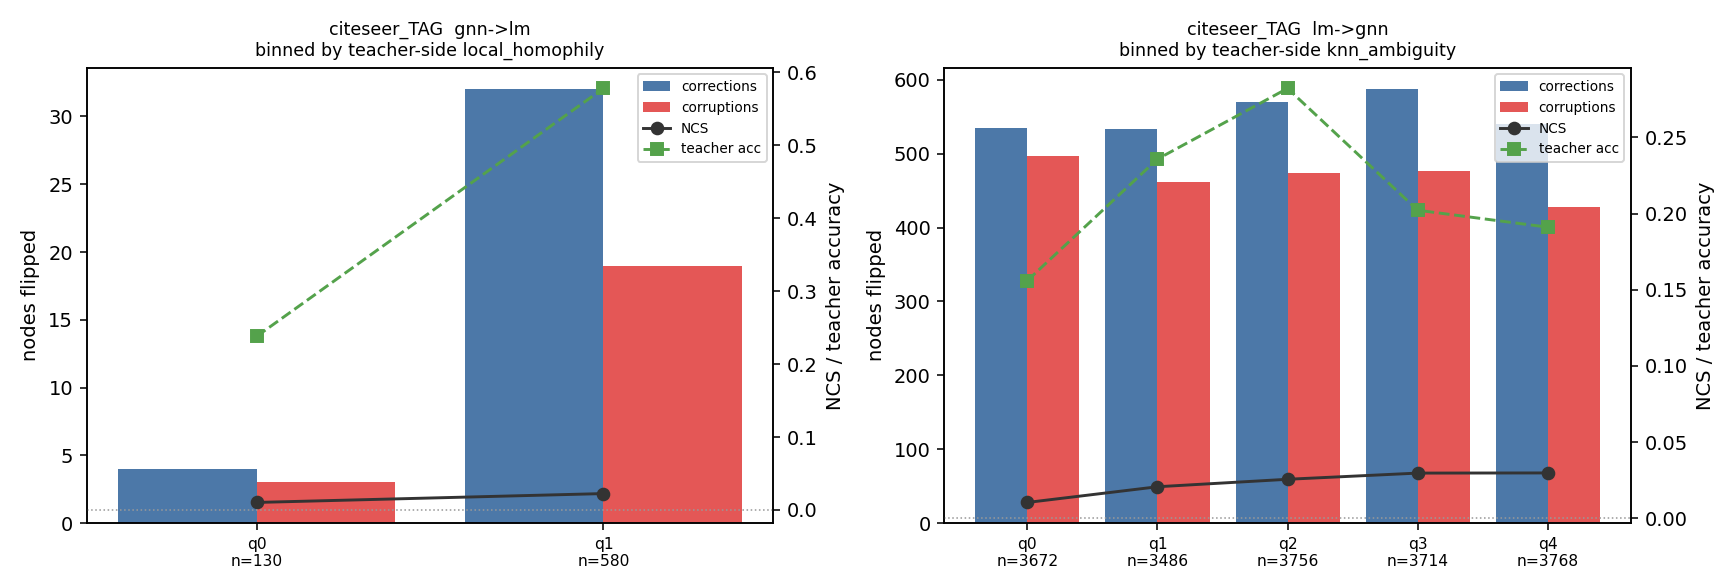

cora


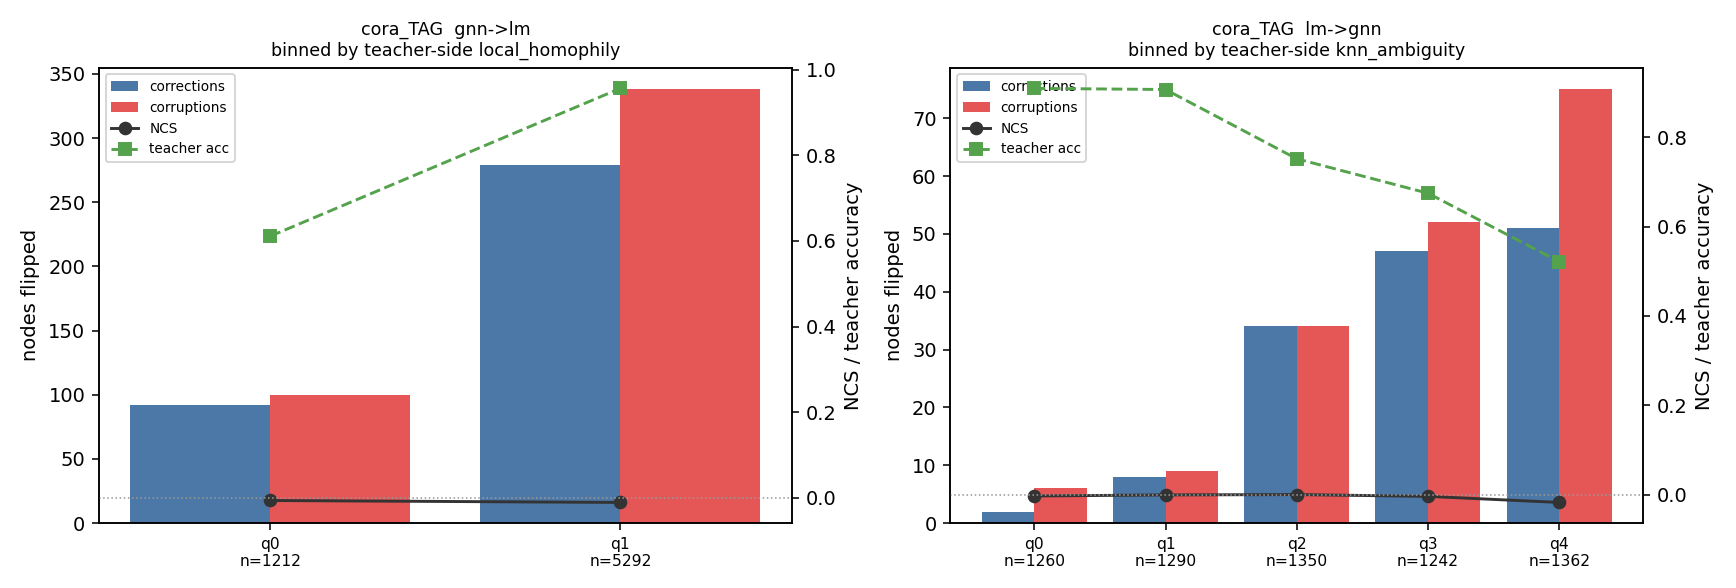

cornell


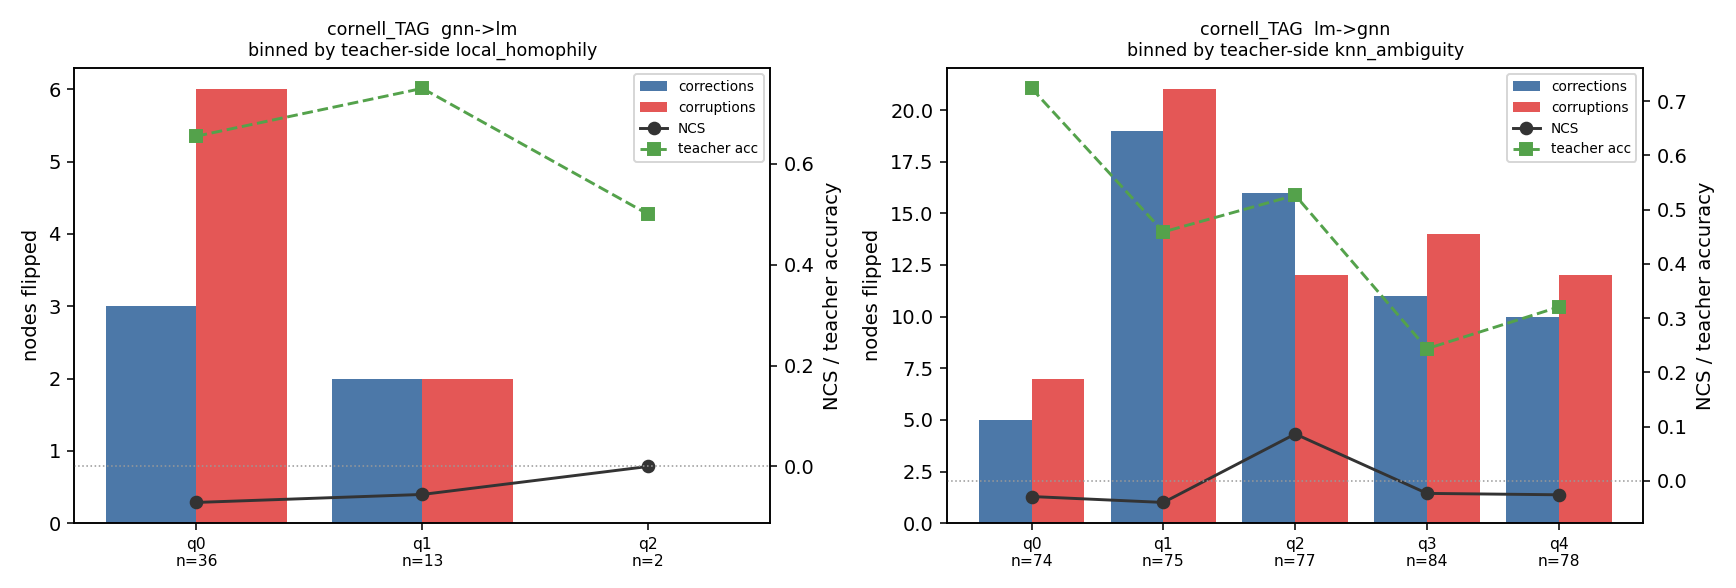

pubmed


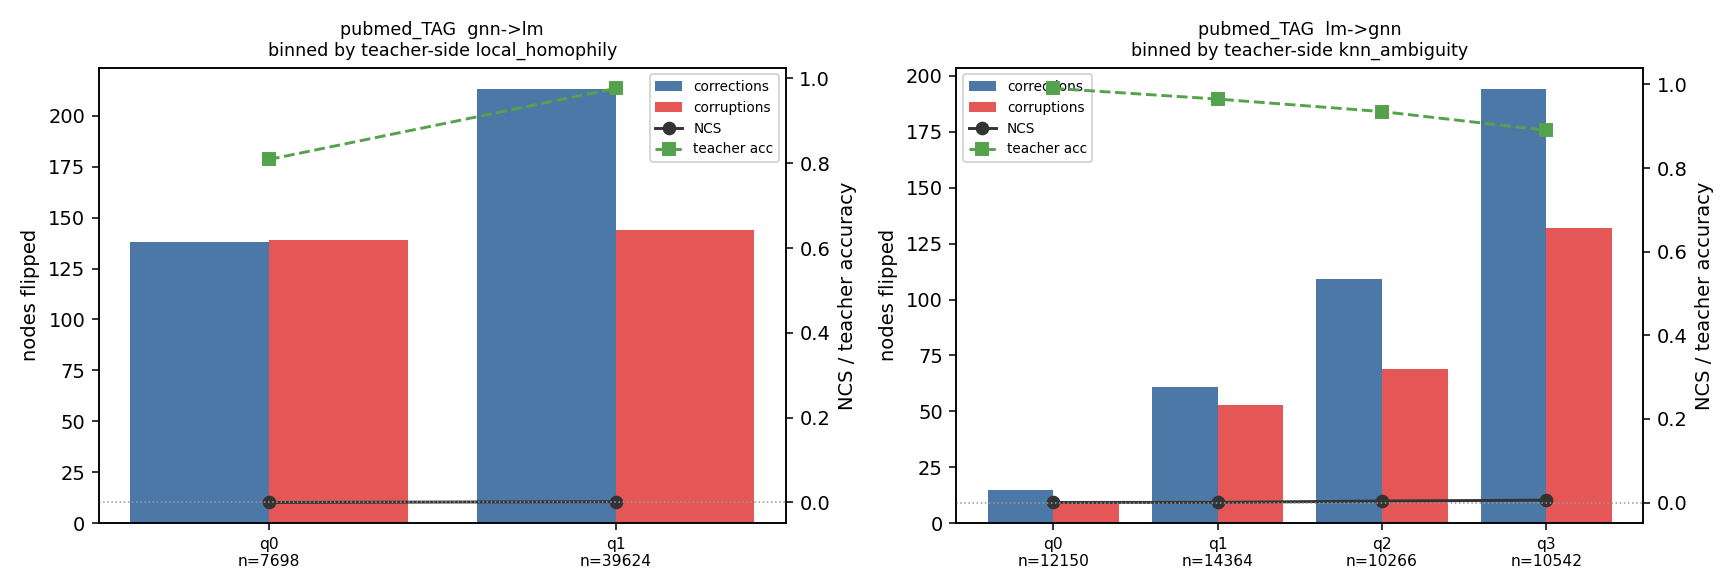

texas


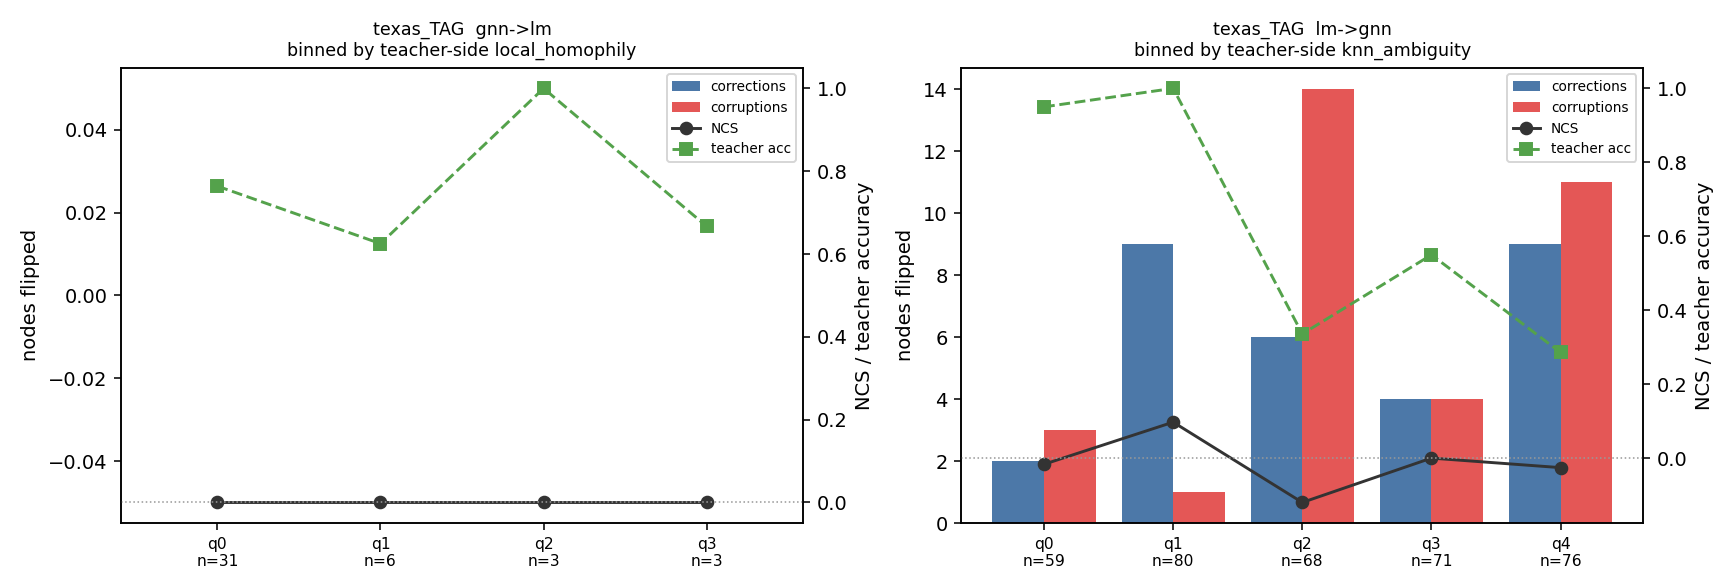

washington


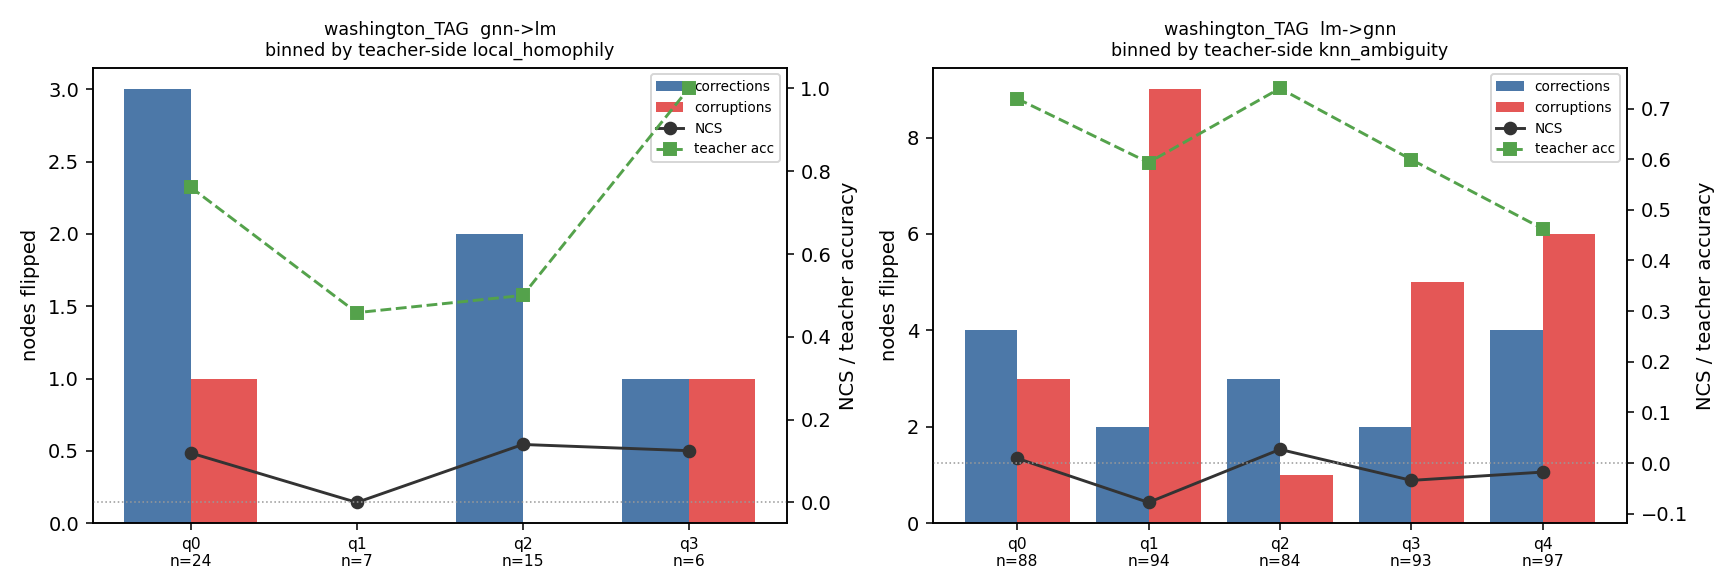

wisconsin


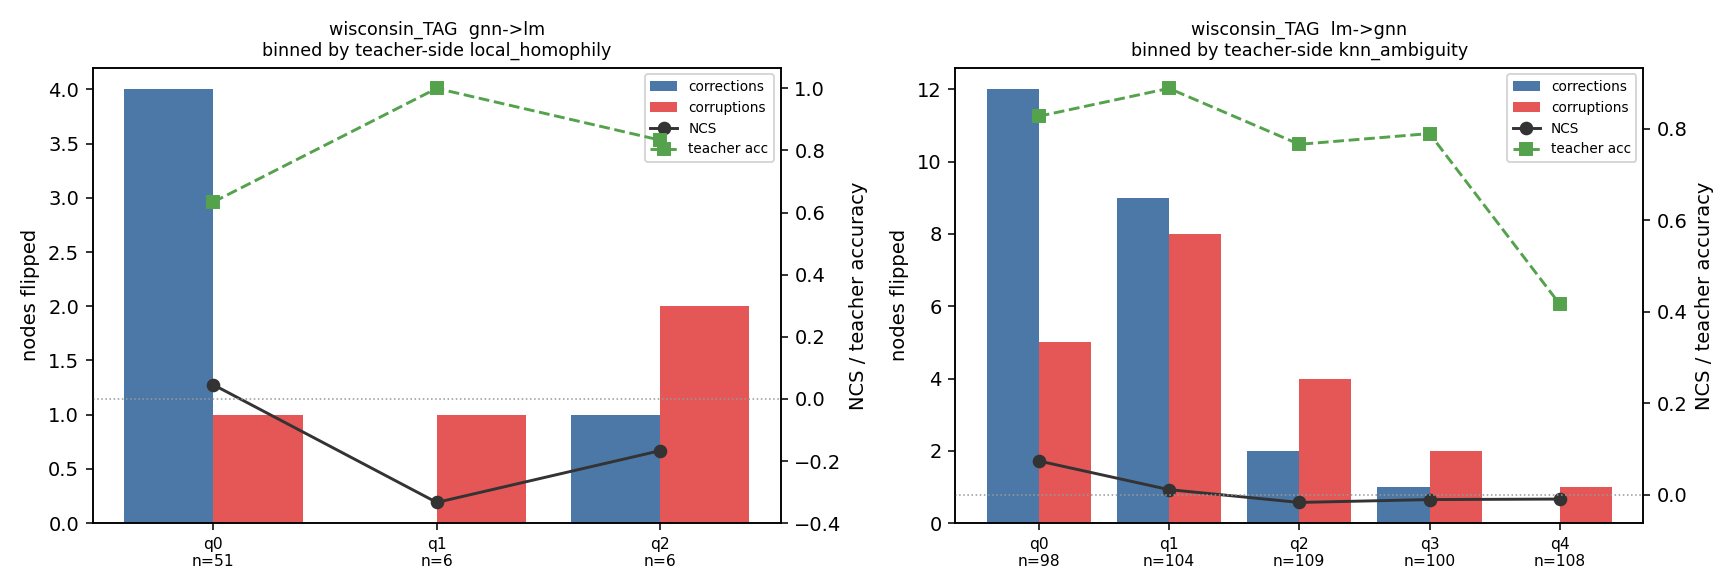

arxiv_TA


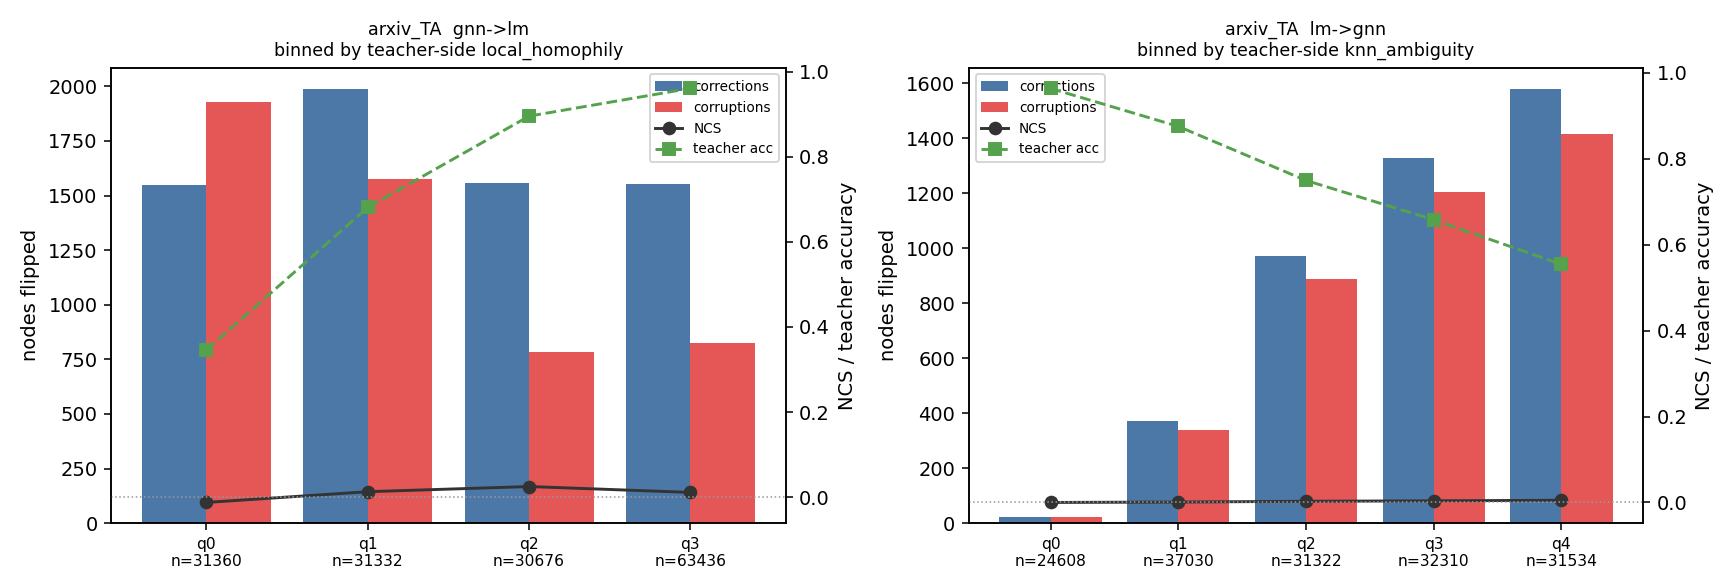

In [98]:
for p in sorted(ANALYSIS.glob('fig_*_TAG.png')) + sorted(ANALYSIS.glob('fig_arxiv*.png')):
    print(p.stem.replace('fig_', '').replace('_TAG', ''))
    display(Image(filename=str(p)))

## 10. Conclusions

**On the research question.** The hypothesis contains two separable claims, and the data
splits them:

1. **Corruption concentrates where the teacher is out of its bias** — *supported*, and
   substantially: 4,000 nodes flipped correct→wrong in a single arxiv E-step, at 5.8× the
   in-bias rate. Whether the *teacher* causes it depends on direction, and the α=β=0
   control separates the two cases cleanly:
   - **LM → GNN** — the control reproduces the concentration (cora 5.22 vs 5.83; pubmed
     6.30 vs 5.59; arxiv 5.08 vs 4.86). Better described as *those nodes are fragile
     under any retraining*.
   - **GNN → LM on arxiv** — the control does **not** (2.77× vs 5.79×, with a flat NCS
     profile against a differentiated one). Here the concentration *is* attributable to
     the pseudo-label term. §6a.
2. **The net effect in those bins is negative** — *not supported anywhere*. Corrections
   outnumber corruptions even out-of-bias, because the teacher, while degraded in
   absolute terms, generally remains no worse than the student (§7). What arxiv shows is
   a *smaller positive*, not a negative — which is why §11 grades it weak rather than
   full support.

**The most useful finding is not the null itself but its cause.** The hypothesis
conflated absolute teacher weakness with weakness *relative to the student*. Only the
latter predicts harm, and on arxiv's E-step the GNN teacher stays marginally ahead of the
LM even where it is worst. A global α that ignores per-node teacher quality is
consequently harder to beat than the hypothesis assumed — not because the teacher's
signal is uniformly valuable, but because it rarely falls below what the student already
had.

**What this cannot say.** Three limits, all preregistered or amended rather than
discovered late:

- **Half the hypothesis was never testable.** GNN→LM has no adequately powered,
  non-degenerate cell outside arxiv (A4, A6), and arxiv is one seed with an unfinished
  control (A7).
- **Only the full-label regime was measured.** Arm 3 (few-shot, 3/5/10 labels per class)
  was withdrawn (A5). Since §8 predicted harm would be strongest where the gold-label CE
  term is too weak to anchor the student, a null at ~54% labelled **cannot** be separated
  from harm masked by that anchor. This is the largest open question.
- **Attribution is imperfect.** The control is a clean single-variable ablation only at
  WebKB's iteration-0 M-step (A9).

**What would settle it**, in descending order of value:

1. **arxiv seeds 1–2 (published + control).** Now the highest-value run in the study,
   not the second: seed 0 already satisfies **Weakly supported** on substance with a
   clean control, and only §10's across-seed stability gate stands between it and a
   scored verdict. Two more seeds per arm decide it. At ~12 h per run alone on the GPU,
   that is roughly two days.
2. **The few-shot sweep (A5, withdrawn).** Directly tests the masking explanation, and
   would show whether the arxiv effect grows as the gold-label anchor weakens.
3. **A direct mechanism test.** Restrict to nodes where the teacher is wrong and the
   student was right, then ask whether the student moved to the *teacher's specific
   label*. This keys on the teacher's own predictions, so it sidesteps both the
   net-flow confound of §7 and the arm-difference confound of A9. Computable from the
   existing archive without retraining.

## Appendix — provenance

| artefact | what it is |
|---|---|
| `EXPERIMENT.md` | preregistration (committed `33a3601`, before any measurement) + amendments A1–A9 |
| `src/probe/` | the instrument: per-step logits archive, signals, NCS/McNemar, verdicts |
| `temp/probe_analysis/ncs_long.csv` | one row per (arm, seed, dataset, iteration, step, direction, axis, bin) |
| `temp/probe_analysis/quadrants.csv` | the 2×2, teacher × student out-of-bias |
| `temp/probe_analysis/verdicts.csv` | §11 applied per (dataset, direction) |
| `logs/probe/manifest.tsv` | every run's exit status and wall time |

**Runs behind this report:** 54 cells on 7 datasets (3 arms × 3 seeds on the four WebKB
configs, 2 arms × 3 seeds on cora/citeseer/pubmed), zero failures, 10.4 h; plus arxiv
published/seed0 (12.1 h) and its α=β=0 control (58.2 h — inflated by an orphaned run
sharing the GPU, see A10). A damaged arxiv `published/seed1` archive was discarded
rather than counted as a second seed (A10).

GLEM's pred files carry no iteration index for `em_iter >= 0`, so each step overwrote the
previous side's logits in place. The instrument archives every write under an
iteration-keyed path — without which no before/after pair survives a run.